# Checkpoint-Trajectory Contamination Audit

Detects whether a benchmark item was plausibly seen during a model's
pretraining by sweeping its **full public checkpoint trajectory**, not just the final weights.

The audit is wrapped in a cryptographic trail (commitment, Merkle root, signature) so the audit is pre-registered and non-repudiable.

**Why checkpoints, not just final weights?** SGD noise accumulates over
training (Jia et al., *Proof-of-Learning*, S&P 2021, Thm. 1), so by the final
checkpoint any one data point's influence is smeared across thousands of
later updates. Checkpoint access thus lets us read the signal right at the moment of exposure, before noise accumulates.


**References**
  - Jia et al., *Proof-of-Learning: Definitions and Practice* (2021). https://arxiv.org/abs/2103.05633
  - Fang et al., *Proof-of-Learning is Currently More Broken Than You Think* (2022). https://arxiv.org/abs/2208.03567
  - Choi, Shavit & Duvenaud, *Tools for Verifying Neural Models' Training Data* (2023). https://arxiv.org/abs/2307.00682
  - Arun et al., *Verde: Verification via Refereed Delegation for Machine Learning Programs* (2025). https://arxiv.org/abs/2502.19405
  - Biderman et al., *Pythia: A Suite for Analyzing Large Language Models Across Training and Scaling* (2023). https://arxiv.org/abs/2304.01373


In [1]:
import hashlib, json, secrets, time
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Memorization heuristic (Choi et al., 2023)

$$M(d, W) = \mathbb{E}_{d' \sim \text{val}}[L(d', W)] - L(d, W)$$

How much better the model does on item $d$ than on held-out validation data,
at checkpoint $W$. Subtracting the validation baseline cancels the shared
"getting better at everything" trend, isolating the item-specific effect.

$$\Delta M(d, i) = M(d, W_i) - M(d, W_{i-1})$$

The step-to-step jump. Spikes sharply right after $d$ was trained on, then decays.

In [2]:
LossFn = Callable[[str, int], float]

@dataclass
class MemorizationTrace:
    item_id: str
    checkpoint_steps: List[int]
    memorization: np.ndarray
    memorization_delta: np.ndarray


def compute_memorization_trace(item_id, checkpoint_steps, loss_fn, validation_ids):
    memorization_values = []

    for step in checkpoint_steps:
        validation_losses = [loss_fn(v, step) for v in validation_ids]
        validation_loss_avg = sum(validation_losses) / len(validation_losses)
        item_loss = loss_fn(item_id, step)
        memorization_values.append(validation_loss_avg - item_loss)

    memorization = np.array(memorization_values)
    memorization_delta = np.diff(memorization)

    return MemorizationTrace(item_id, list(checkpoint_steps), memorization, memorization_delta)


def contamination_score(trace):
    peak_idx = int(np.argmax(trace.memorization_delta))
    peak_step = trace.checkpoint_steps[peak_idx + 1]

    return {
        "item_id": trace.item_id,
        "peak_step": peak_step,
        "peak_delta": float(trace.memorization_delta[peak_idx]),
        "max_memorization": float(np.max(trace.memorization)),
    }

## Commit-then-reveal

Publish a commitment to the exact audit scope (model, checkpoints, items)
before running anything, so a skeptical reader can confirm the scope
wasn't quietly narrowed after seeing which items looked suspicious. Standard
hash commitment: computationally binding and hiding.

In [3]:
def _sha256(data):
    return hashlib.sha256(data).digest()


def _hash_item(item):
    item_json = json.dumps(item, sort_keys=True, default=str)
    return _sha256(item_json.encode("utf-8"))


@dataclass
class Commitment:
    commitment_hex: str
    nonce_hex: str
    n_items: int

    def to_dict(self):
        return {
            "commitment": self.commitment_hex,
            "nonce": self.nonce_hex,
            "n_items": self.n_items
        }


def compute_commitment(items, nonce=None):
    if nonce is None:
        nonce = secrets.token_bytes(32)
    item_hashes = b""
    for item in items:
        item_hashes += _hash_item(item)
    digest = _sha256(item_hashes + nonce)

    return Commitment(digest.hex(), nonce.hex(), len(items))


def verify_commitment(items, commitment):
    nonce = bytes.fromhex(commitment.nonce_hex)
    recomputed = compute_commitment(items, nonce=nonce)

    return recomputed.commitment_hex == commitment.commitment_hex

## Merkle commitment over checkpoints

A single Merkle root over all ~150 checkpoint hashes lets an auditor request $O(\log n)$-size membership proofs for just the checkpoints behind whatever looked suspicious, instead of re-hashing everything.

A standard binary hash tree: leaves are hashed, then combined pairwise up to a single root.

In [4]:
def _hash_bytes(data):
    return hashlib.sha256(data).digest()


def _hash_pair(left, right):
    return _hash_bytes(left + right)


@dataclass
class MerkleProof:
    leaf_index: int
    siblings: List[Tuple[bytes, str]]

class MerkleTree:
    def __init__(self, leaves: List[bytes]):

        self.leaf_hashes = [_hash_bytes(leaf) for leaf in leaves]
        self.levels: List[List[bytes]] = [self.leaf_hashes]

        level = self.leaf_hashes
        while len(level) > 1:
            next_level = []
            for i in range(0, len(level), 2):
                left = level[i]
                if i + 1 < len(level):
                    right = level[i + 1]
                else:
                    right = level[i]
                next_level.append(_hash_pair(left, right))
            self.levels.append(next_level)
            level = next_level

    @property
    def root(self) -> bytes:
        return self.levels[-1][0]

    def root_hex(self) -> str:
        return self.root.hex()

    def get_proof(self, leaf_index):
        siblings = []
        idx = leaf_index
        for level in self.levels[:-1]:
            if idx % 2 == 1:
                sibling_index = idx - 1
                side = "L"
            else:
                sibling_index = min(idx + 1, len(level) - 1)
                side = "R"
            siblings.append((level[sibling_index], side))
            idx = idx // 2

        return MerkleProof(leaf_index, siblings)


def verify_proof(leaf, proof, root):
    acc = _hash_bytes(leaf)
    for sibling_hash, side in proof.siblings:
        if side == "R":
            acc = _hash_pair(acc, sibling_hash)
        else:
            acc = _hash_pair(sibling_hash, acc)

    return acc == root

## Real checkpoint hashing

Hash each tensor individually, sorted by name, name included in the hash,
at a fixed dtype/device (float32, CPU); precision, device and dtype must
match between prover and verifier.

In [5]:
def _tensor_to_canonical_bytes(tensor):
    try:
        import torch
        if isinstance(tensor, torch.Tensor):
            return tensor.detach().to("cpu", dtype=torch.float32).contiguous().numpy().tobytes()
    except ImportError:
        pass
    return np.ascontiguousarray(np.asarray(tensor, dtype=np.float32)).tobytes()


def hash_state_dict(state_dict):
    names = sorted(state_dict.keys())
    tensor_hashes = b""
    for name in names:
        tensor_bytes = _tensor_to_canonical_bytes(state_dict[name])
        tensor_hashes += hashlib.sha256(name.encode("utf-8") + b":" + tensor_bytes).digest()

    return hashlib.sha256(tensor_hashes).digest()

## Ed25519 signing for non-repudiation

Signs the (Merkle root, scope commitment) pair, so the prover can't later
disown the report and any post-signing edit is detectable -- the same role
a timestamped signature plays in Jia et al.'s PoL protocol (§V-A).

In [6]:
from cryptography.exceptions import InvalidSignature
from cryptography.hazmat.primitives.asymmetric.ed25519 import Ed25519PrivateKey, Ed25519PublicKey
from cryptography.hazmat.primitives import serialization


@dataclass
class KeyPair:
    private_key: Ed25519PrivateKey
    public_key: Ed25519PublicKey

    def public_key_hex(self):
        return self.public_key.public_bytes(serialization.Encoding.Raw, serialization.PublicFormat.Raw).hex()


def generate_keypair():
    priv = Ed25519PrivateKey.generate()

    return KeyPair(priv, priv.public_key())


def _payload_to_canonical_bytes(payload):
    return json.dumps(payload, sort_keys=True, default=str).encode("utf-8")


def sign_report(payload, keypair):
    return keypair.private_key.sign(_payload_to_canonical_bytes(payload)).hex()


def verify_report(payload, signature_hex, public_key_hex):
    try:
        Ed25519PublicKey.from_public_bytes(bytes.fromhex(public_key_hex)).verify(bytes.fromhex(signature_hex), _payload_to_canonical_bytes(payload))
        return True
    except (InvalidSignature, ValueError):
        return False

## The Pythia checkpoint schedule

154 checkpoints: `step0`, 10 log-spaced early checkpoints `step{1,...,512}`, then every 1000 steps to `step143000`, with training data order fixed and documented.

In [7]:
EARLY_STEPS: List[int] = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
LATE_STEPS: List[int] = list(range(1000, 143001, 1000))
DEFAULT_PYTHIA_STEPS: List[int] = EARLY_STEPS + LATE_STEPS

VALID_PYTHIA_SIZES = ["70m", "160m", "410m", "1b", "1.4b", "2.8b", "6.9b", "12b"]

def load_pythia_checkpoint(model_size, step):
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    name, revision = f"EleutherAI/pythia-{model_size}", f"step{step}"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = AutoModelForCausalLM.from_pretrained(name, revision=revision).to(device)
    tokenizer = AutoTokenizer.from_pretrained(name, revision=revision)

    return model, tokenizer


def make_pythia_loss_fn(model_size, item_texts):
    import torch
    loss_cache: Dict[Tuple[str, int], float] = {}

    def _compute_all_at_step(step):
        model, tokenizer = load_pythia_checkpoint(model_size, step)
        device = next(model.parameters()).device
        model.eval()

        with torch.no_grad():
            for item_id, text in item_texts.items():
                ids = tokenizer(text, return_tensors="pt").to(device)
                loss_cache[(item_id, step)] = float(model(**ids, labels=ids["input_ids"]).loss.item())
        del model, tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def loss_fn(item_id, step):
        if (item_id, step) not in loss_cache:
            _compute_all_at_step(step)
        return loss_cache[(item_id, step)]

    return loss_fn


def hash_checkpoint_from_pretrained(model_size, step):
    model, _ = load_pythia_checkpoint(model_size, step)
    return hash_state_dict(model.state_dict())

print(f"{len(DEFAULT_PYTHIA_STEPS)} checkpoints: {DEFAULT_PYTHIA_STEPS[:5]} ... {DEFAULT_PYTHIA_STEPS[-3:]}")

154 checkpoints: [0, 1, 2, 4, 8] ... [141000, 142000, 143000]


## Orchestration

We first commit the scope, then sweep memorization traces for every benchmark item and rank it by suspicion (`peak_delta`). We then Merkle-commit the checkpoint set we consulted, prove membership only for checkpoints behind the top-Q
flagged items (Jia et al.'s verification-budget idea, §V-C) and finally sign the report.

In [8]:
def build_audit_manifest(model_size, checkpoint_steps, benchmark_item_ids, validation_item_ids):
    config = {
        "model_size": model_size,
        "checkpoint_steps": list(checkpoint_steps),
        "benchmark_item_ids": list(benchmark_item_ids),
        "validation_item_ids": list(validation_item_ids),
    }
    return {
        "config": config,
        "commitment": compute_commitment([config]).to_dict(),
        "created_at": time.time()
    }


def checkpoint_hash_placeholder(step):
    return hashlib.sha256(f"checkpoint:{step}".encode()).digest()


CheckpointHashFn = Callable[[str, int], bytes]


def run_contamination_audit(model_size, checkpoint_steps, benchmark_items, validation_items,
    loss_fn, top_q = 5, checkpoint_hash_fn = None, signing_keypair = None):

    if checkpoint_hash_fn is None:
        checkpoint_hash_fn = lambda m, s: checkpoint_hash_placeholder(s)

    manifest = build_audit_manifest(model_size, checkpoint_steps, benchmark_items, validation_items)

    traces = {}
    scores = []

    for item_id in benchmark_items:
        trace = compute_memorization_trace(item_id, checkpoint_steps, loss_fn, validation_items)
        traces[item_id] = trace
        scores.append(contamination_score(trace))
    scores.sort(key=lambda s: s["peak_delta"], reverse=True)

    checkpoint_leaves = []
    for step in checkpoint_steps:
        checkpoint_leaves.append(checkpoint_hash_fn(model_size, step))
    tree = MerkleTree(checkpoint_leaves)

    top_items = scores[:top_q]
    flagged_steps_set = set()
    for s in top_items:
        flagged_steps_set.add(s["peak_step"])
    flagged_steps = sorted(flagged_steps_set)

    proofs = {}
    for step in flagged_steps:
        idx = list(checkpoint_steps).index(step)
        leaf = checkpoint_hash_fn(model_size, step)
        proof = tree.get_proof(idx)
        proofs[step] = {"proof_valid": verify_proof(leaf, proof, tree.root), "leaf_index": idx}

    result = {
        "manifest": manifest, "scores": scores, "merkle_root": tree.root_hex(),
        "proofs_for_flagged_checkpoints": proofs, "traces": traces,
    }

    if signing_keypair is not None:
        payload = {
            "merkle_root": result["merkle_root"],
            "scope_commitment": manifest["commitment"]["commitment"],
            "n_checkpoints": len(checkpoint_steps),
        }
        result["signature"] = {
            "payload": payload,
            "signature_hex": sign_report(payload, signing_keypair),
            "public_key_hex": signing_keypair.public_key_hex(),
        }
    return result

##Real run on ARC-Easy (plausible leakage) and GPQA (negative control)

In [9]:
!pip install -q transformers datasets huggingface_hub

In [10]:
from huggingface_hub import login
login()


In [11]:
def load_benchmark_items_real(n_items = 50, n_validation = 20):
    from datasets import load_dataset

    arc = load_dataset("allenai/ai2_arc", "ARC-Easy", split="test")
    gpqa = load_dataset("Idavidrein/gpqa", "gpqa_main", split="train")

    item_texts, benchmark_ids = {}, []
    for i, row in enumerate(arc.select(range(min(n_items, len(arc))))):
        item_id = f"arc_easy_{i}"
        gold = row["choices"]["text"][row["choices"]["label"].index(row["answerKey"])]
        item_texts[item_id] = f"Question: {row['question']}\nAnswer: {gold}"
        benchmark_ids.append(item_id)

    n_negative_control = min(n_items, len(gpqa))
    for i, row in enumerate(gpqa.select(range(n_negative_control))):
        item_id = f"gpqa_{i}"
        item_texts[item_id] = f"Question: {row['Question']}\nAnswer: {row['Correct Answer']}"
        benchmark_ids.append(item_id)

    validation_ids = []
    for i, row in enumerate(gpqa.select(range(n_negative_control, n_negative_control + n_validation))):  # disjoint slice
        item_id = f"gpqa_val_{i}"
        item_texts[item_id] = f"Question: {row['Question']}\nAnswer: {row['Correct Answer']}"
        validation_ids.append(item_id)

    return item_texts, benchmark_ids, validation_ids


def run_pythia_audit(model_size = "70m"):
    item_texts, benchmark_ids, validation_ids = load_benchmark_items_real()
    loss_fn = make_pythia_loss_fn(model_size, item_texts)
    checkpoint_steps = DEFAULT_PYTHIA_STEPS
    checkpoint_hash_fn = lambda m, s: hash_checkpoint_from_pretrained(m, s)

    kp = generate_keypair()
    res = run_contamination_audit(
        model_size=model_size, checkpoint_steps=checkpoint_steps,
        benchmark_items=benchmark_ids, validation_items=validation_ids,
        loss_fn=loss_fn, top_q=min(10, len(benchmark_ids)),
        checkpoint_hash_fn=checkpoint_hash_fn, signing_keypair=kp,
    )
    res["item_texts"] = item_texts

    for s in res["scores"]:
        print(s)
    sig = res["signature"]
    print("\nMerkle root:", res["merkle_root"])
    print("Signature verifies:", verify_report(sig["payload"], sig["signature_hex"], sig["public_key_hex"]))

    return res



In [14]:
def empirical_pvalue(score: float, null_scores: np.ndarray) -> float:
    """One-sided empirical p-value: how many null (clean) scores are at
    least as extreme as this one? +1 smoothing (Davison & Hinkley, 1997)
    so a finite null sample never gives p=0."""
    count_as_extreme = 0
    for null_score in null_scores:
        if null_score >= score:
            count_as_extreme += 1
    return (count_as_extreme + 1) / (len(null_scores) + 1)


def benjamini_hochberg(pvalues, q=0.05):
    """Benjamini-Hochberg step-up FDR control. Returns {item_id: flagged}."""
    items_sorted_by_pvalue = sorted(pvalues.items(), key=lambda pair: pair[1])
    m = len(items_sorted_by_pvalue)

    largest_passing_rank = 0
    for rank, (item_id, pvalue) in enumerate(items_sorted_by_pvalue, start=1):
        threshold = (rank / m) * q
        if pvalue <= threshold:
            largest_passing_rank = rank

    decisions = {}
    for rank, (item_id, pvalue) in enumerate(items_sorted_by_pvalue, start=1):
        decisions[item_id] = rank <= largest_passing_rank
    return decisions

def evaluate_scores(scores_by_item, negative_control_prefix = "gpqa_", test_prefix = "arc_easy_", q = 0.05):
    null_scores_list = []
    test_scores = {}
    for item_id, score in scores_by_item.items():
        if item_id.startswith(negative_control_prefix):
            null_scores_list.append(score)
        elif item_id.startswith(test_prefix):
            test_scores[item_id] = score
    null_scores = np.array(null_scores_list)

    pvalues = {}
    for item_id, score in test_scores.items():
        pvalues[item_id] = empirical_pvalue(score, null_scores)
    decisions = benjamini_hochberg(pvalues, q=q)

    n_flagged = 0
    for flagged in decisions.values():
        if flagged:
            n_flagged += 1

    print(f"Null calibrated from {len(null_scores)} GPQA (negative-control) items.")
    print(f"{n_flagged}/{len(test_scores)} items flagged as contaminated at FDR<={q:.0%}.")
    return decisions


def evaluate_real_run(res, negative_control_prefix = "gpqa_", test_prefix = "arc_easy_", q = 0.05):
    scores_by_item = {}
    for s in res["scores"]:
        scores_by_item[s["item_id"]] = s["peak_delta"]
    return evaluate_scores(scores_by_item, negative_control_prefix, test_prefix, q)

In [15]:
res = run_pythia_audit(model_size="70m")
decisions = evaluate_real_run(res)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

{'item_id': 'gpqa_26', 'peak_step': 512, 'peak_delta': 1.529009675979614, 'max_memorization': 0.2296907901763916}
{'item_id': 'gpqa_44', 'peak_step': 256, 'peak_delta': 1.2895336151123047, 'max_memorization': 2.070989036560059}
{'item_id': 'gpqa_48', 'peak_step': 1000, 'peak_delta': 1.1841936111450195, 'max_memorization': 0.6512313127517699}
{'item_id': 'gpqa_19', 'peak_step': 1000, 'peak_delta': 0.9297547340393066, 'max_memorization': 1.5716984272003174}
{'item_id': 'gpqa_13', 'peak_step': 128, 'peak_delta': 0.8360459327697765, 'max_memorization': 0.828409576416016}
{'item_id': 'arc_easy_29', 'peak_step': 26000, 'peak_delta': 0.7256370544433595, 'max_memorization': -0.3592866420745846}
{'item_id': 'arc_easy_3', 'peak_step': 43000, 'peak_delta': 0.7189321994781492, 'max_memorization': -0.1314872264862057}
{'item_id': 'gpqa_41', 'peak_step': 1000, 'peak_delta': 0.6980941295623779, 'max_memorization': 1.5457493662834167}
{'item_id': 'arc_easy_35', 'peak_step': 43000, 'peak_delta': 0.6798

### From a raw ranking to a real finding

The raw FDR check above can come back with nothing flagged even when
there's a real signal, for a specific reason: a small model like
pythia-70m is extremely volatile in its first few thousand training
steps; any item's loss swings wildly there for purely generic reasons,
contaminated or not. Those early swings dominate `peak_delta` for almost
every item, and once GPQA's spurious early spikes are as large as
ARC-Easy's, they inflate the FDR null threshold enough to swamp a smaller, later, genuinely item-specific signal.

The fix: confirm the early window really is shared/generic. Average
`memorization` within a group of items at each checkpoint; independent
per-item signal cancels out under averaging, a shared anomaly doesn't.
Then re-run the same scoring and FDR logic restricted to checkpoints past
that window.

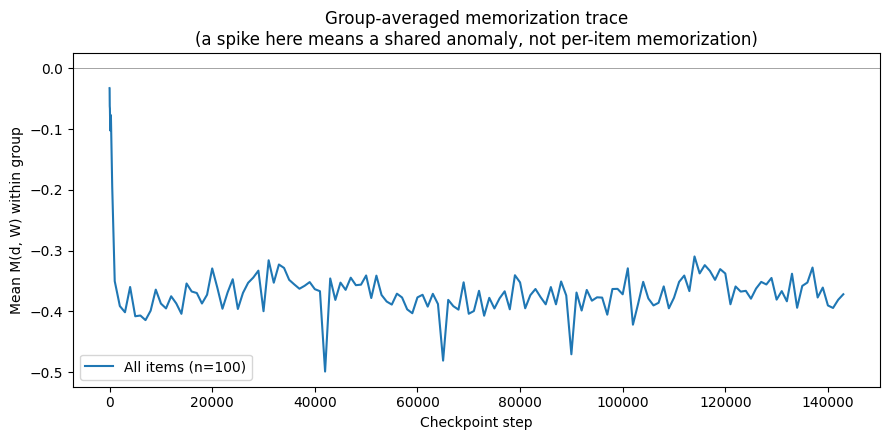

In [16]:
def plot_group_average_traces(res, prefixes, zoom = None):
    checkpoint_steps = next(iter(res["traces"].values())).checkpoint_steps

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for label, prefix in prefixes.items():
        item_ids = [item_id for item_id in res["traces"] if item_id.startswith(prefix)]
        if not item_ids:
            continue
        group_average = []
        for step_idx in range(len(checkpoint_steps)):
            values_at_this_step = [res["traces"][item_id].memorization[step_idx] for item_id in item_ids]
            group_average.append(sum(values_at_this_step) / len(values_at_this_step))
        ax.plot(checkpoint_steps, group_average, label=f"{label} (n={len(item_ids)})")

    ax.axhline(0, color="gray", linewidth=0.5)
    if zoom is not None:
        ax.set_xlim(zoom)
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("Mean M(d, W) within group")
    ax.set_title("Group-averaged memorization trace\n(a spike here means a shared anomaly, not per-item memorization)")
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_group_average_traces(res, prefixes={"All items": ""})

In [17]:
def _trace_from_step(trace, min_step: int):
    first_kept = len(trace.checkpoint_steps) - 1
    for i, step in enumerate(trace.checkpoint_steps):
        if step >= min_step:
            first_kept = max(0, i - 1)
            break

    kept_steps = trace.checkpoint_steps[first_kept:]
    kept_memorization = trace.memorization[first_kept:]
    return MemorizationTrace(trace.item_id, kept_steps, kept_memorization, np.diff(kept_memorization))


def compute_late_checkpoint_scores(res, min_step = 5000):
    scores = []
    for item_id, trace in res["traces"].items():
        sliced_trace = _trace_from_step(trace, min_step)
        if len(sliced_trace.memorization_delta) == 0:
            continue
        scores.append(contamination_score(sliced_trace))
    scores.sort(key=lambda s: s["peak_delta"], reverse=True)
    return scores


def evaluate_late_checkpoints(res, min_step = 5000, negative_control_prefix = "gpqa_", test_prefix = "arc_easy_", q = 0.05):
    scores_by_item = {}
    for s in compute_late_checkpoint_scores(res, min_step):
        scores_by_item[s["item_id"]] = s["peak_delta"]
    return evaluate_scores(scores_by_item, negative_control_prefix, test_prefix, q)


print("=== Top 10, checkpoints >= 5000 only ===")
for s in compute_late_checkpoint_scores(res, min_step=5000)[:10]:
    print(f"  {s['item_id']:14s} peak_delta={s['peak_delta']:+.3f}  peak_step={s['peak_step']}")

print()
decisions_late = evaluate_late_checkpoints(res, min_step=5000)

=== Top 10, checkpoints >= 5000 only ===
  arc_easy_29    peak_delta=+0.726  peak_step=26000
  arc_easy_3     peak_delta=+0.719  peak_step=43000
  arc_easy_35    peak_delta=+0.680  peak_step=43000
  arc_easy_14    peak_delta=+0.675  peak_step=91000
  arc_easy_38    peak_delta=+0.651  peak_step=43000
  arc_easy_15    peak_delta=+0.638  peak_step=43000
  arc_easy_21    peak_delta=+0.621  peak_step=43000
  arc_easy_26    peak_delta=+0.586  peak_step=43000
  arc_easy_1     peak_delta=+0.574  peak_step=43000
  arc_easy_19    peak_delta=+0.566  peak_step=43000

Null calibrated from 50 GPQA (negative-control) items.
28/50 items flagged as contaminated at FDR<=5%.


In [18]:
late_scores_by_id = {}
for s in compute_late_checkpoint_scores(res, min_step=5000):
    late_scores_by_id[s["item_id"]] = s

flagged_ids = []
for item_id, flagged in decisions_late.items():
    if flagged:
        flagged_ids.append(item_id)

print(f"{len(flagged_ids)} flagged items, by peak_step:")
step_counts = {}
for item_id in flagged_ids:
    step = late_scores_by_id[item_id]["peak_step"]
    step_counts[step] = step_counts.get(step, 0) + 1

for step, count in sorted(step_counts.items(), key=lambda kv: -kv[1]):
    print(f"  step {step:6d}: {count:2d} items ({count / len(flagged_ids):.0%} of flagged)")

print("\nSensitivity of the flagged count to min_step:")
for cutoff in [3000, 5000, 8000, 15000, 30000, 60000]:
    n_flagged = 0
    for flagged in evaluate_late_checkpoints(res, min_step=cutoff).values():
        if flagged:
            n_flagged += 1
    print(f"  min_step={cutoff:6d}: {n_flagged}/{len(res['scores'])} flagged")

28 flagged items, by peak_step:
  step  43000: 15 items (54% of flagged)
  step  91000:  4 items (14% of flagged)
  step 114000:  2 items (7% of flagged)
  step  26000:  1 items (4% of flagged)
  step  31000:  1 items (4% of flagged)
  step   9000:  1 items (4% of flagged)
  step  57000:  1 items (4% of flagged)
  step  88000:  1 items (4% of flagged)
  step  56000:  1 items (4% of flagged)
  step  19000:  1 items (4% of flagged)

Sensitivity of the flagged count to min_step:
Null calibrated from 50 GPQA (negative-control) items.
29/50 items flagged as contaminated at FDR<=5%.
  min_step=  3000: 29/100 flagged
Null calibrated from 50 GPQA (negative-control) items.
28/50 items flagged as contaminated at FDR<=5%.
  min_step=  5000: 28/100 flagged
Null calibrated from 50 GPQA (negative-control) items.
28/50 items flagged as contaminated at FDR<=5%.
  min_step=  8000: 28/100 flagged
Null calibrated from 50 GPQA (negative-control) items.
28/50 items flagged as contaminated at FDR<=5%.
  min

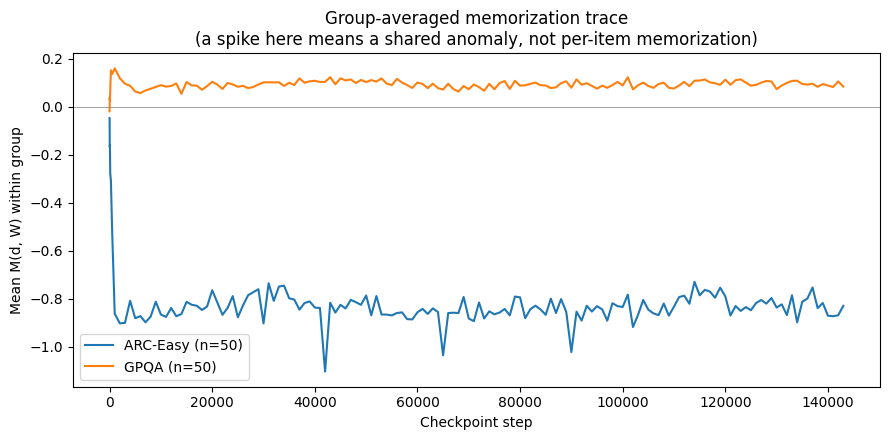

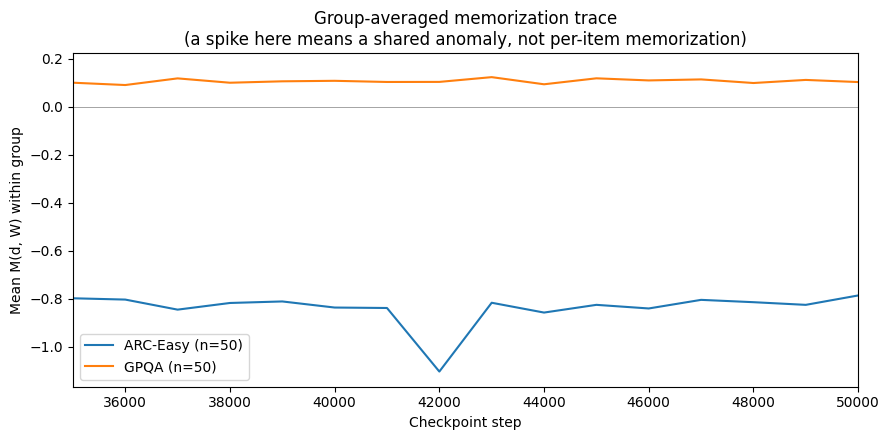

In [19]:
plot_group_average_traces(res, prefixes={"ARC-Easy": "arc_easy_", "GPQA": "gpqa_"})
plot_group_average_traces(res, prefixes={"ARC-Easy": "arc_easy_", "GPQA": "gpqa_"}, zoom=(35000, 50000))  # zoomed on the dominant flagged checkpoint